In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_secondary_structure)=
# Get secondary structure

*Assigning secondary structure per residue using DSSP rules.*

The function {func}`molsysmt.structure.get_secondary_structure` assigns secondary structure categories (such as $\alpha$-helices, $\beta$-strands, and coils) to amino acid residues across single structures or simulation trajectories using the DSSP algorithm.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_secondary_structure`.
:::


## Basic usage

Let's show how to assign 3-state secondary structure categories for TcTIM (PDB ID: 1TCD):


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import numpy as np


In [3]:
molsys = msm.convert(msm.systems['TcTIM']['1tcd.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


By default, {func}`molsysmt.structure.get_secondary_structure` uses the simplified 3-state classification: `'H'` (helix), `'E'` (extended strand), and `'C'` (coil/loop):


In [4]:
ss_3state = msm.structure.get_secondary_structure(molsys, simplified=True)
print('Secondary structure array shape:', ss_3state.shape)
print('First 25 residue assignments:', ss_3state[0, :25])


Secondary structure array shape: (1, 662)
First 25 residue assignments: ['C' 'C' 'C' 'C' 'E' 'E' 'E' 'E' 'E' 'C' 'C' 'E' 'C' 'C' 'C' 'H' 'H' 'H'
 'H' 'H' 'H' 'H' 'H' 'H' 'H']


## Full 8-state DSSP assignment

Setting `simplified=False` returns the detailed 8-category DSSP classification (`'H'`, `'B'`, `'E'`, `'G'`, `'I'`, `'T'`, `'S'`, `' '`):


In [5]:
ss_8state = msm.structure.get_secondary_structure(molsys, simplified=False)
print('First 25 residues in 8-state classification:', ss_8state[0, :25])


First 25 residues in 8-state classification: [' ' ' ' ' ' ' ' 'E' 'E' 'E' 'E' 'E' ' ' ' ' 'B' ' ' ' ' ' ' 'H' 'H' 'H'
 'H' 'H' 'H' 'H' 'H' 'H' 'H']


## Visualizing secondary structure composition

We plot the overall secondary structure composition across the protein:


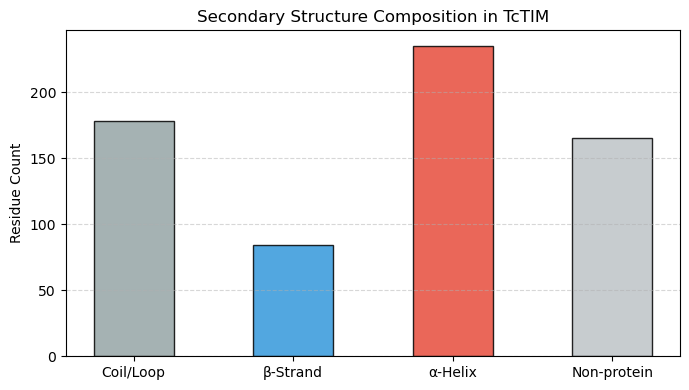

In [6]:
unique_states, counts = np.unique(ss_3state[0], return_counts=True)
state_labels = {'H': 'α-Helix', 'E': 'β-Strand', 'C': 'Coil/Loop', 'NA': 'Non-protein'}
labels = [state_labels.get(s, s) for s in unique_states]
colors = {'H': '#e74c3c', 'E': '#3498db', 'C': '#95a5a6', 'NA': '#bdc3c7'}
bar_colors = [colors.get(s, '#7f8c8d') for s in unique_states]

plt.figure(figsize=(7, 4))
plt.bar(labels, counts, color=bar_colors, edgecolor='black', alpha=0.85, width=0.5)
plt.ylabel('Residue Count')
plt.title('Secondary Structure Composition in TcTIM')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Select <Tutorial_Select>`: Select specific residues and atom groups with {func}`molsysmt.basic.select`.
- {ref}`Get dihedral angles <Tutorial_Get_dihedral_angles>`: Compute backbone Ramachandran angles with {func}`molsysmt.structure.get_dihedral_angles`.
- {ref}`Get sequence alignment <Tutorial_Get_sequence_alignment>`: Align amino acid sequences with {func}`molsysmt.topology.get_sequence_alignment`.
:::
